# YasMarina — Centerline vs. Raceline
Plots the track centerline (with left/right boundaries) and the minimum-time raceline coloured by velocity.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image

MAP_DIR = Path('.').resolve()
CENTERLINE_CSV = MAP_DIR / 'YasMarina_centerline.csv'
RACELINE_CSV   = MAP_DIR / 'traj_race_cl_centerline_mintime_mue1.0489_YasMarina_map.csv'
MAP_YAML       = MAP_DIR / 'YasMarina_map.yaml'
MAP_PNG        = MAP_DIR / 'YasMarina_map.png'

In [2]:
# Centerline: comma-separated, columns x_m, y_m, w_tr_right_m, w_tr_left_m
cl = pd.read_csv(CENTERLINE_CSV, comment='#', header=None,
                 names=['x', 'y', 'w_right', 'w_left'])

# Raceline: semicolon-separated, columns s_m; x_m; y_m; psi_rad; kappa_radpm; vx_mps; ax_mps2
rl = pd.read_csv(RACELINE_CSV, sep=';', comment='#', header=None,
                 names=['s', 'x', 'y', 'psi', 'kappa', 'vx', 'ax'])

# Compute left/right boundary points from centerline using local heading
dx = np.gradient(cl['x'].values)
dy = np.gradient(cl['y'].values)
norm = np.hypot(dx, dy)
nx, ny = -dy / norm, dx / norm   # left-normal
cl['xl'] = cl['x'] + nx * cl['w_left']
cl['yl'] = cl['y'] + ny * cl['w_left']
cl['xr'] = cl['x'] - nx * cl['w_right']
cl['yr'] = cl['y'] - ny * cl['w_right']

print(f'Centerline: {len(cl)} points')
print(f'Raceline:   {len(rl)} points, vx range = [{rl.vx.min():.2f}, {rl.vx.max():.2f}] m/s')

Centerline: 1110 points
Raceline:   1964 points, vx range = [1.62, 12.00] m/s


In [3]:
# Optional: load occupancy map for background context
with open(MAP_YAML) as f:
    map_cfg = yaml.safe_load(f)
img = np.array(Image.open(MAP_PNG))
res = map_cfg['resolution']
ox, oy = map_cfg['origin'][0], map_cfg['origin'][1]
h, w = img.shape[:2]
extent = [ox, ox + w * res, oy, oy + h * res]

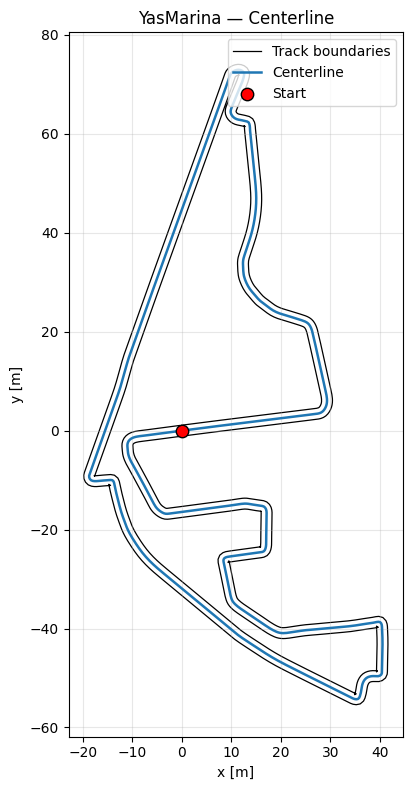

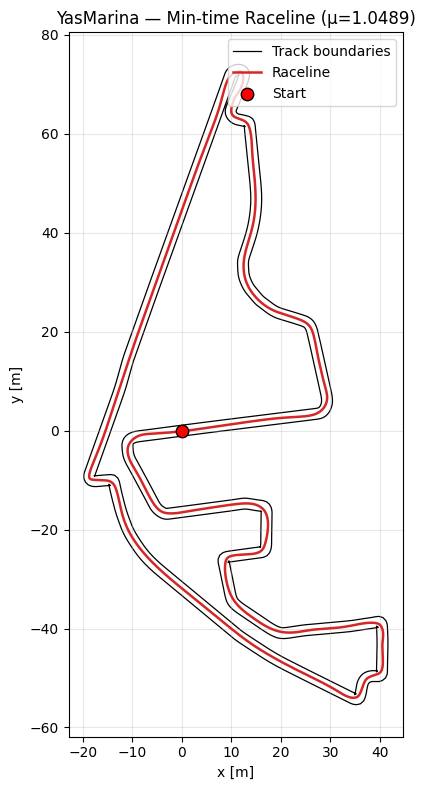

In [8]:
# Plot 1 — Centerline with track boundaries
fig1, ax1 = plt.subplots(figsize=(10, 8))
# ax1.imshow(img, cmap='gray', extent=extent, origin='lower', alpha=0.35, zorder=0)
ax1.plot(cl['xl'], cl['yl'], color='black', lw=0.9, zorder=1, label='Track boundaries')
ax1.plot(cl['xr'], cl['yr'], color='black', lw=0.9, zorder=1)
ax1.plot(cl['x'],  cl['y'],  color='tab:blue', lw=1.8, zorder=2, label='Centerline')
ax1.scatter(cl['x'].iloc[0], cl['y'].iloc[0], color='red', s=80, marker='o',
            edgecolor='black', zorder=3, label='Start')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_title('YasMarina — Centerline')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig(MAP_DIR / 'centerline.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Raceline waypoints
fig2, ax2 = plt.subplots(figsize=(10, 8))
# ax2.imshow(img, cmap='gray', extent=extent, origin='lower', alpha=0.35, zorder=0)
ax2.plot(cl['xl'], cl['yl'], color='black', lw=0.9, zorder=1, label='Track boundaries')
ax2.plot(cl['xr'], cl['yr'], color='black', lw=0.9, zorder=1)
ax2.plot(rl['x'], rl['y'], color='tab:red', lw=1.8, zorder=2, label='Raceline')
ax2.scatter(rl['x'].iloc[0], rl['y'].iloc[0], color='red', s=80, marker='o',
            edgecolor='black', zorder=3, label='Start')
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_title('YasMarina — Min-time Raceline (μ=1.0489)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(MAP_DIR / 'raceline.png', dpi=150, bbox_inches='tight')
plt.show()
